## Supervised Learning: A Quick Recap

Supervised learning is a type of machine learning where we **train a model using labeled data**.  

That means each data point has:
- An **input** (also called features)
- A known **output** (label or value)

The goal is to teach the model how to map inputs to outputs so it can make accurate predictions on unseen data.

There are two main types of supervised learning:
- **Classification**: It is used when the output is a **category or class**. In classification, the model picks a **label** from a fixed set of possible answers. (e.g. Is a network connection **normal** or **malicious**?)
- **Regression**: It is used when the output is a **number (a continuous value)**. 
In regression, the model tries to learn a formula that outputs a number — not a category. (e.g. Estimating **download time** based on file size)


## 📝 Exercise 1: Simple Linear Regression

In this first exercise, we will explore **linear regression models**, starting with a simple case where we model an output variable $y$ as a linear function of a single input feature $x$.

We will work with linear models of the form:  $y = \beta_0+\beta_1 x + \epsilon$

where:
- $\beta_0$: the **intercept** (value of $y$ when $x = 0$)  
- $\beta_1$: the **slope** (how much $y$ changes for a one-unit increase in $x$)  
- $\epsilon$: a **random error term** that accounts for noise or variability not explained by the linear relationship

This setup is the foundation of a **linear regression model**.

We assume that the random error term $\epsilon$ follows a **normal distribution** $\epsilon \sim \mathcal{N}(0,\sigma^2)$ where:

- The **mean** of the noise is zero.
- The **variance** of the noise is $\sigma^2$, so the standard deviation is $\sigma$.
- The noise is **independent** of $x$, and each observation is **i.i.d.** (independent and identically distributed).

As a means of example, let us consider the linear model: $y=b_0+b_1x+\epsilon$

with:
- $b_0 = 2$ (intercept)
- $b_1 = 3$ (slope)
- $\sigma = 30$ (standard deviation of the noise)

Note that at the end of the example, you can experiment with different values to your own choice to see how they affect the data and the fitted model.

In this case:
- $y$ is the value we **observe or measure** when the input feature takes the value $x$.
- The **sample size** (i.e., number of data points) is denoted by $n$.

### Preparation: Generating "Synthetic Data"

#### Step 1: Import Required Libraries

First, let's import the necessary libraries for data manipulation, visualization and regression modeling.

In [1]:
pip install matplotlib numpy pandas statsmodels scikit-learn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.1 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.3 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.3 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.3 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.3 MB 1.1 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.3 MB 1.1 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.3 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.3 MB 

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random
import statsmodels.api as sm
from sklearn import datasets, linear_model

We define the true underlying parameters of the linear model and the sample size to simulate synthetic data for regression analysis.


In [3]:
# Define parameters for synthetic data generation
n = 20 # sample size
b0 = 2 # real intercept (unobserved)
b1 = np.array([3]) # real slope (unobserved)

In [4]:
print(b1)

[3]


Now, to simulate data for our linear model $y = \beta_0 + \beta_1 x + \epsilon$, we’ll follow these steps:

#### Step 2: Define the Random Error Term ($\epsilon$)

The error term $\epsilon$ represents random noise in the data. It is sampled from a normal distribution with a specified mean and standard deviation.


In [5]:
# Mean and standard deviation for the error term
mue, sigmae = 0, 30

# Set a random seed to make results reproducible,
# if you want to fix a 'random' vector and not have different vectors per call:
np.random.seed(199)

# Generate the error vector Er of size n
Er = np.random.normal(mue, sigmae, n)
print("Error vector (Er):", Er)

Error vector (Er): [ 33.24214448  -9.66833454  68.66231565 -55.3634741  -46.02241369
  32.69834474  36.28414203  -8.77906033 -28.89190806   6.07129635
  48.70306245 -69.33409712  31.09989668  70.21805685  -6.69218164
 -19.60951679  24.44625946 -12.92376476  -0.37686216  39.06455214]


#### Step 3: Generate the Feature Input ($x$)

We assume that $x$, our input feature, lies within an interval $[xl, xh]$. We randomly sample $n$ values from this range using a uniform distribution.

In [6]:
# Define bounds for x
xl, xh = 0, 120

# Fixing seed again
np.random.seed(199)

# Generate n values of x uniformly between xl and xh
x = np.random.uniform(xl,xh,n)
print("Input feature vector (x):", x)

Input feature vector (x): [ 78.57500336 117.84471417  47.98856377 101.29831222  55.66108205
  65.38116798  74.337341    39.82041465 117.71944956  31.32134616
 112.80089673   5.39719021  50.41908488  99.59823395  69.68557585
  13.90856407  13.01791564 107.00400554  53.31687507  64.69449614]


#### Step 4: Compute the Output Variable ($y$)

Using the linear model and the generated values of n-sized vectors Er and x, we compute the corresponding values of y.

In [7]:
# Compute y using the model
y = b0 + b1[0] * x + Er
print("Output variable (y):", y)

Output variable (y): [270.96715455 345.86580798 214.62800697 250.53146256 122.96083245
 230.84184868 261.29616502 112.6821836  326.26644061 102.03533484
 389.10575263 -51.1425265  184.35715132 371.01275871 204.36454591
  24.11617543  65.50000638 310.08825187 161.57376303 235.14804055]


#### Step 5: Visualize the Data

Let us plot the line $y=2+3x$ (without noise) as well as the generated points $y$ that include the error.

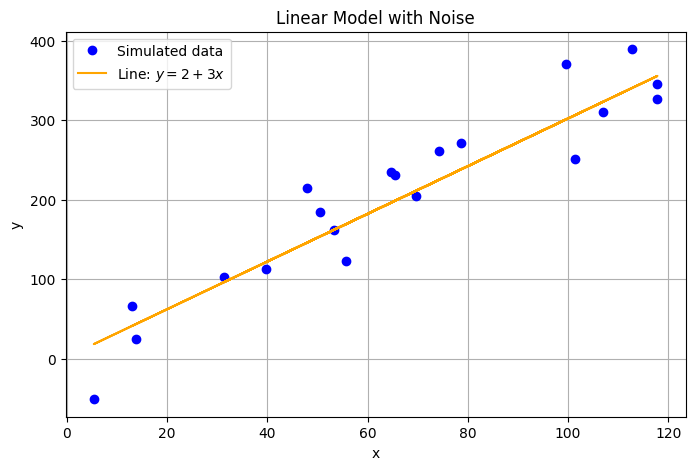

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(x, y, 'o', color='blue', label='Simulated data')
plt.plot(x, b0+b1*x, color='orange',  label='Line: $y = 2 + 3x$')

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Linear Model with Noise")
plt.grid(True)
plt.show()

#### Step 6: Wrap It Up Into a Function

To make the data generation process reusable, we define the function `genSample()` that creates synthetic data for both **simple** and **multiple linear regression** tasks.

- The function accepts a `seed` parameter:
  - If `seed` is set to an **integer**, the random values are reproducible — the same `x`, `y`, and `Er` vectors are generated every time.
  - If `seed` is left **empty**, the random values change with each call.


- The `size` parameter controls the number of features in the input vector `x`:
  - If `size = 1`, it generates data for **simple linear regression** (one feature).
  - If `size > 1`, it produces inputs for **multiple linear regression** (multiple features).

This structure allows you to generate controlled or randomized data for different types of regression experiments. Keep in mind that this process will be needed for later TP sessions.

In [9]:
def genSample(n, b0, b1, sigmae, xLow, xHigh, seedit=199, size=1):
    if type(seedit) == int:
        np.random.seed(seedit)
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed(seedit + k)
            x.append(np.random.uniform(xl, xh, n))
    else:
        np.random.seed()
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed()
            x.append(np.random.uniform(xl, xh, n))
        
    # Compute y
    y = b0 + Er
    for k in range(size):
        y += b1[k] * x[k]

    # Output
    if size == 1:
        return (x[0], y, Er)
    else:
        return (x, y, Er)

In [10]:
# Generate synthetic data
n, b0, b1 = 20, 2, np.array([3])
(x, y, Er) = genSample(n, b0, b1, sigmae, xl, xh, seedit=199, size=1)
print("x = ", x)
print("y = ", y)
print("Er = ", Er)

x =  [ 78.57500336 117.84471417  47.98856377 101.29831222  55.66108205
  65.38116798  74.337341    39.82041465 117.71944956  31.32134616
 112.80089673   5.39719021  50.41908488  99.59823395  69.68557585
  13.90856407  13.01791564 107.00400554  53.31687507  64.69449614]
y =  [270.96715455 345.86580798 214.62800697 250.53146256 122.96083245
 230.84184868 261.29616502 112.6821836  326.26644061 102.03533484
 389.10575263 -51.1425265  184.35715132 371.01275871 204.36454591
  24.11617543  65.50000638 310.08825187 161.57376303 235.14804055]
Er =  [ 33.24214448  -9.66833454  68.66231565 -55.3634741  -46.02241369
  32.69834474  36.28414203  -8.77906033 -28.89190806   6.07129635
  48.70306245 -69.33409712  31.09989668  70.21805685  -6.69218164
 -19.60951679  24.44625946 -12.92376476  -0.37686216  39.06455214]


In [11]:
# Create a pandas DataFrame and put the x, Er, y vectors
df_slr = pd.DataFrame({'x': x, 'y': y, 'error': Er})
df_slr

,x,y,error
0,78.575003,270.967155,33.242144
1,117.844714,345.865808,-9.668335
2,47.988564,214.628007,68.662316
3,101.298312,250.531463,-55.363474
4,55.661082,122.960832,-46.022414
5,65.381168,230.841849,32.698345
6,74.337341,261.296165,36.284142
7,39.820415,112.682184,-8.779060
8,117.719450,326.266441,-28.891908
9,31.321346,102.035335,6.071296


### Part A: Analyzing synthetic data

In this part, you will analyze the synthetic dataset you generated using basic statistical tools and linear regression formulas.

You may use either `numPy` or `pandas` for your calculations.

With the above synthetic data: 

* a) Compute the sample means $\bar{x}$, $\bar{y}$ and the sample variance $s_{xx}$ and covariance $s_{xy}$ .

* b) Using the formulas presented in the lecture, calculate the estimated coefficients of the least-squares line: $\hat{y}=\hat{\beta}_0+\hat{\beta}_1x$. Compare your estimated coefficients with the **true values** used to generate the data: $(\beta_0,\beta_1)=(2,3)$ What do you observe? How close are they? What could explain any differences?

* c) Plot the regression line, least-squares line and the data samples on the same graph. Use appropriate labels and a legend to clearly distinguish each line and the data points.

**Optional:** You can later compare your results with those from `scikit-learn` implementation of simple linear regression.

#### Answer:

In [12]:
## TODO:
## a)
# Compute sample means
x_mean = np.mean(x)
y_mean = np.mean(y)

# Compute variance and covariance
s_xx = np.sum((x - x_mean)**2)
s_xy = np.sum((x - x_mean)*(y - y_mean))

print("Mean of x:", x_mean)
print("Mean of y:", y_mean)
print("s_xx (sample variance of x):", s_xx)
print("s_xy (sample covariance of x,y):", s_xy)

Mean of x: 65.98951164926079
Mean of y: 206.60995782891467
s_xx (sample variance of x): 23768.781822302182
s_xy (sample covariance of x,y): 74797.9674317648


In [13]:
## b)
# Estimate slope and intercept
beta1_hat = s_xy / s_xx
beta0_hat = y_mean - beta1_hat * x_mean

print("Estimated slope (β1̂):", beta1_hat)
print("Estimated intercept (β0̂):", beta0_hat)

# Compare with true values
print("True values: β0 = 2, β1 = 3")

Estimated slope (β1̂): 3.1468994915667943
Estimated intercept (β0̂): -1.052402828885164
True values: β0 = 2, β1 = 3


### What do you observe? How close are they? What could explain any differences?

The estimated slope is very close to the true value (only about +0.147 higher)

The estimated intercept is lower than the true value (off by about −3.05)

The intercept often varies more than the slope

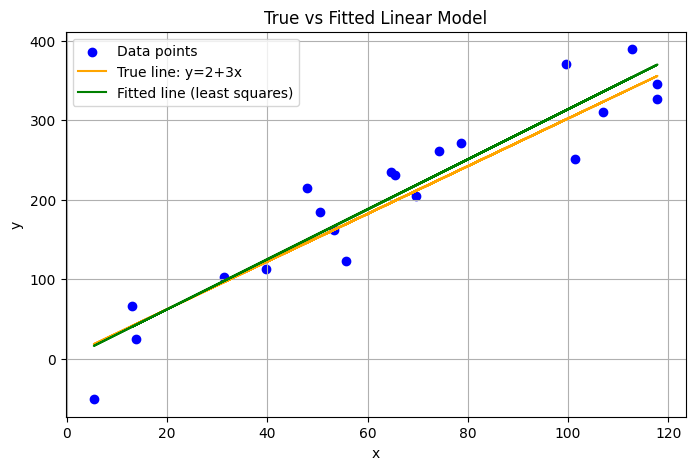

In [14]:
## c)
# Compute predicted values
y_true_line = 2 + 3 * x
y_hat_line = beta0_hat + beta1_hat * x

# Sort by x for smoother line plotting
#sorted_idx = np.argsort(x)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_true_line, color='orange', label='True line: y=2+3x')
plt.plot(x, y_hat_line, color='green', label='Fitted line (least squares)')
plt.xlabel("x")
plt.ylabel("y")
plt.title("True vs Fitted Linear Model")
plt.legend()
plt.grid(True)
plt.show()

### Part B: Visualizing data distribution

In this section, you'll explore the distribution of the input feature $x$ using visual tools. You can use either `matplotlib` or `pandas` for this part.

* d) Create a boxplot of the variable $x$ to examine its distribution. This will help you identify the spread, central tendency and possible outliers.

* e) Based on the boxplot, how would you describe the distribution of $x$? Symmetric, left-skewed, right-skewed or uniform?

* f) What does the interquartile range (IQR) tell you about the spread of $x$ values?

* g) Are there any outliers in the feature $x$ based on the boxplot? What would cause them to appear or not appear in a asynthetic dataset like this?

#### Answer:

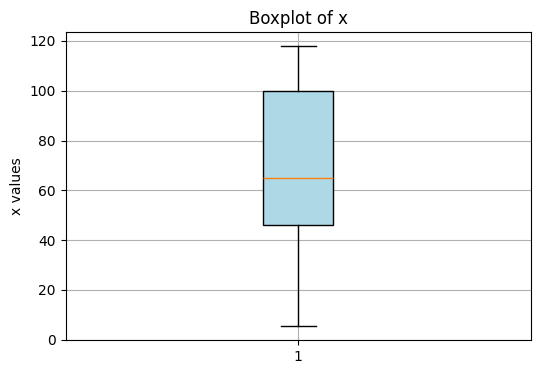

In [15]:
## TODO:
# d) 
plt.figure(figsize=(6, 4))
plt.boxplot(x, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title("Boxplot of x")
plt.ylabel("x values")
plt.grid(True)
plt.show()

### (e) Based on the boxplot, how would you describe the distribution of x?

Based on the boxplot, the distribution of *x* appears to be right-skewed.  
The distance between the median and the upper quartile (Q3) is larger than that between the median and the lower quartile (Q1),  
which means that higher values of *x* are more spread out toward the upper end of the range (close to 120).

In [16]:
# f) 
q1 = np.percentile(x, 25)
q3 = np.percentile(x, 75)
iqr = q3 - q1
print("IQR:", iqr)

IQR: 54.07672702843945


### f) What does the interquartile range (IQR) tell you about the spread of $x$ values?
The IQR of 54.08 indicates that the middle 50% of x values are spread over 54 units, showing moderate variability.

### g) Are there any outliers in the feature $x$ based on the boxplot? What would cause them to appear or not appear in a asynthetic dataset like this?

Based on the boxplot, there are no outliers in the feature *x*.

*x* was generated from a uniform distribution with fixed bounds (0 to 120)
In such synthetic datasets, values are evenly spread within the interval, so outliers do not occur.

### Part C: Evaluating Model Accuracy

In this section, you will assess how well your regression model fits the synthetic data using standard evaluation metrics. These metrics help quantify the accuracy and reliability of your predictions.

* h) Compute the Residual Standard Error (RSE) and the Mean Squared Error (MSE). What do they tell about the accuracy of the model?

* **Reminder:** The relationship between MSE and RSE is given by: $MSE := \frac{1}{n}RSS = \frac{n-2}{n}RSE^2$.

* i) Compute the coefficient of determination ($R^2$-statistic). What does it tell about the accuracy of the model?

* j) Calculate the $95\%$ confidence intervals for the estimated coefficients. Do the real coefficients $\beta_0=2$ and $\beta_1=3$ fall within these intervals?

**Optional:** You may compare your manually calculated metrics and intervals with those obtained using `scikit-learn`'s `LinearRegression` implementation.

#### Answer:

In [17]:
## TODO:
# Residuals
residuals = y - y_hat_line

# RSS
RSS = np.sum(residuals**2)

# MSE
MSE = RSS / n

# RSE
RSE = np.sqrt(RSS / (n - 2))

print("Residual Standard Error (RSE):", RSE)
print("Mean Squared Error (MSE):", MSE)


Residual Standard Error (RSE): 40.02266221186426
Mean Squared Error (MSE): 1441.6321414724885


### What do they tell about the accuracy of the model?

Both RSE and MSE show that the model fits the data reasonably well, but is not perfect because the synthetic dataset contains noise.

In [18]:
# i)
TSS = np.sum((y - np.mean(y))**2)
R2 = 1 - RSS / TSS

print("R^2 statistic:", R2)

R^2 statistic: 0.8908740377860237


### What does it tell about the accuracy of the model?

The R² value of 0.891 indicates that the model explains most of the variation in the data

In [19]:
# j) 
from scipy import stats

# Sample size
n = len(x)

# t critical value for 95% confidence
t_val = stats.t.ppf(0.975, df=n-2)

# Residual variance (RSE squared)
RSE2 = RSE**2

# Variance of beta1 and beta0
var_beta1 = RSE2 / np.sum((x - np.mean(x))**2)
var_beta0 = RSE2 * (1/n + (np.mean(x)**2)/np.sum((x - np.mean(x))**2))

# Standard errors
SE_beta1 = np.sqrt(var_beta1)
SE_beta0 = np.sqrt(var_beta0)

# 95% confidence intervals
CI_beta1 = (beta1_hat - t_val*SE_beta1, beta1_hat + t_val*SE_beta1)
CI_beta0 = (beta0_hat - t_val*SE_beta0, beta0_hat + t_val*SE_beta0)

print("95% CI for beta1:", CI_beta1)
print("95% CI for beta0:", CI_beta0)

# Check if true values fall within the intervals
print("Does beta1=3 fall in the CI?", CI_beta1[0] <= 3 <= CI_beta1[1])
print("Does beta0=2 fall in the CI?", CI_beta0[0] <= 2 <= CI_beta0[1])


95% CI for beta1: (np.float64(2.601502863521329), np.float64(3.6922961196122595))
95% CI for beta0: (np.float64(-41.6581056863896), np.float64(39.55330002861927))
Does beta1=3 fall in the CI? True
Does beta0=2 fall in the CI? True


## 📝 Exercise 2: Multiple Linear Regression

In this exercise, we will extend simple linear regression to a **multi-variable setting**. Specifically, we work on problems of multi-linear regression with multiple input features and examine how each input feature contributes to predicting the output variable.

We work with a multiple linear regression model using 4 input features. 

The regression model is: $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3 + \beta_4x_4 + \epsilon$

where:
- $x_1$, $x_2$, $x_3$ are features that influence $y$
- $x_4$ is constructed as noise: $x_4=np.ones(n)+Er$, meaning it should not have any true effect on the target $y$.

### Step 1: Generate Synthetic Data

We use the `genSample()` function again to simulate a dataset with multiple features. You can adjust the number of features via the `size` parameter.

- The model is still based on: $Y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_d x_d + \varepsilon$
- We'll use a fixed seed for reproducibility.
- The noise term $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ adds randomness, simulating real-world measurement error.

In [20]:
# Define parameters for synthetic data generation
n = 100 # sample size
b0 = 2 # real intercept (unobserved)
b1 = np.array([3, 7, 20])   # real slope (unobserved) for 3 input features
xl, xh = 0, 120 # input range for features
sigmae = 30 # standard deviation for error term

In [21]:
# Generate synthetic data using the true model and added Gaussian noise
(xM,yM,ErM) = genSample(n, b0, b1, sigmae, xl, xh, seedit=199, size=len(b1))
x_extra = 1 + ErM   # This variable has no real meaning, just noise centered around 1
xM.append(x_extra)  # Now xM has 4 features: [x1, x2, x3, x_extra]
yM += xM[-1]        # Modify yM so x_extra appears to influence y

In [22]:
print(yM)

[1374.59143316 2322.41128171 2250.1457926  2499.20761193 2430.67457419
  603.03144279 1240.84471637 1223.2975139  1228.84556236 1499.16907077
 2823.44584723 1064.82124983 2061.4550658  2379.35528987 1141.33204466
 2225.65132135 2838.42783066 2535.61484818  899.74684007 2953.37597083
 2586.15126712 1904.57251949 2798.49385947 1564.53643238  843.19351725
 1705.06592061 3038.94434881 1607.89010131 2044.1491482  1563.84630176
 1524.1596561  2871.42813784 1124.82185876  554.16862787  551.20571631
 1702.60523197 3015.23440047 2246.28701629  796.45276835 1220.07497433
  926.99206868 3053.44119167 1080.74276669 2756.56529521 2734.98416951
 2003.73426609 3109.82957323 1282.146597   1042.88788648 3205.27338971
 1189.34624714 2728.54299268 2383.936162   2162.09892745  806.079352
 2609.48527952 1089.45325648 1100.71951851 1788.14922082 2279.43038676
 2433.5690629  2304.41480271 2061.85896636 2824.99717094 1705.81316954
 2129.02038638 1070.59806814 2916.79492476 1373.64092616 2649.90898385
  565.13

### Step 2: Visualize Data

We collect the generated features, target variable, and noise into a structured format using a `pandas.DataFrame`.

In [23]:
# Create a structured DataFrame for visual inspection
dataM = {'x1': xM[0], 'x2' : xM[1],'x3' : xM[2] ,'x4': xM[3], 'error': ErM, 'y_mult': yM}
df_slrM = pd.DataFrame(data=dataM)
df_slrM

,x1,x2,x3,x4,error,y_mult
0,78.575003,113.715871,13.668552,34.242144,33.242144,1374.591433
1,117.844714,27.185691,89.745699,-8.668335,-9.668335,2322.411282
2,47.988564,71.330417,73.327127,69.662316,68.662316,2250.145793
3,101.298312,51.397042,97.163016,-54.363474,-55.363474,2499.207612
4,55.661082,91.696882,85.542899,-45.022414,-46.022414,2430.674574
...,...,...,...,...,...,...
95,8.854235,61.968206,60.400340,20.917828,19.917828,1711.182607
96,25.821316,81.436553,113.898221,49.849389,48.849389,3026.183015
97,28.996218,8.222232,1.510316,4.260805,3.260805,184.272200
98,45.852941,104.255477,104.346202,23.016888,22.016888,3001.304969


### Step 3: Analysis & Interpretation of Regression Results

Now that you’ve generated and organized the synthetic dataset, analyze the statistical properties of the regression models and understand the role of each input feature.

* a) For the above multi-regression model, estimate the unknown regression coefficients $(\beta_0,...,\beta_4)$ using all four features. Also compute the p-values, F-statistic and $R^2$ score for each feature. What do the p-values and F-statistic tell you about which features are truly significant?

* b) Fit a multi-regression model only using $(x_2,x_4)$. Estimate the coefficients and determine the p-values, F-statistic and $R^2$ score again. How do the p-values and F-statistic compare with results from part (a)? What does this imply? Are all the features relevant to the model?

* c) Fit four seperate single-feature regression models (one for each variable $x_i$). Compare the estimated slopes $\beta_1$, $\ldots$, $\beta_4$ from these single-variable models to those from the multi-variable model in part (a). What do you notice?

* d) Compare the answers from (a), (b), (c). What do you observe? Explain.

**Hint 1:** Use `LinearRegression()` from `scikit-learn` and create a linear regression object.

**Hint 2:** For the p-values and the F-statistic, you can use the scikit-learn command `sklearn.feature_selection.f_regression`

scikit documnetation: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_regression.html

#### Answer:

Here is the answer for part (a) using `statsmodels`, you need to do it with `scikit-learn`.

In [24]:
# using pandas
Xm = df_slrM[["x1", "x2", "x3", "x4"]]
Ym = df_slrM["y_mult"]
Xm = sm.add_constant(Xm) ## let's add an intercept (beta_0) to our model

# Note the difference in argument order
model = sm.OLS(Ym, Xm).fit()
y_pred_OLS = model.predict(Xm) # make the predictions using SAME train data

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 y_mult   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.952e+31
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:55:17   Log-Likelihood:                 2693.8
No. Observations:                 100   AIC:                            -5378.
Df Residuals:                      95   BIC:                            -5364.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0000   1.55e-13   6.43e+12      0.000       1.000       1.000
x1             3.0000   1.44e-15   2.08e+15      0.000       3.000       3.000
x2             7.0000   1.37e-15    5.1e+15      0.000       7.000       7.000
x3            20.0000   1.41e-15   1.42e+16      0.000      20.000      20.000
x4             2.0000   1.67e-15    1.2e+15      0.000       2.000       2.000
==============================================================================
Omnibus:                        5.489   Durbin-Watson:                   1.101
Prob(Omnibus):                  0.064   Jarque-Bera (JB):                4.834
Skew:                          -0.491   Prob(JB):                       0.0892
Kurtosis:                       3.441   Cond. No.                         350.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
## TODO:
# a)
# Import necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression

X_all = df_slrM[['x1', 'x2', 'x3', 'x4']]
y_all = df_slrM['y_mult']

# Fit model
model_all = LinearRegression()
model_all.fit(X_all, y_all)

# Calculate F-statistic and p-values (like in your example)
F_all, p_all = f_regression(X_all, y_all)

# Display results
print("=== (a) Multiple Linear Regression with all features ===")
print("Estimated coefficients:", [model_all.intercept_] + list(model_all.coef_))
print("R^2 score:", model_all.score(X_all, y_all))
print("F-statistic:", F_all)
print("p-values:", p_all)
print("\n")

=== (a) Multiple Linear Regression with all features ===
Estimated coefficients: [np.float64(1.0000000000006821), np.float64(2.9999999999999964), np.float64(7.000000000000004), np.float64(19.999999999999986), np.float64(2.000000000000003)]
R^2 score: 1.0
F-statistic: [3.05020455e+00 1.28893175e+01 6.51847108e+02 1.15579041e-04]
p-values: [8.38602784e-02 5.18371247e-04 4.27953400e-45 9.91444148e-01]




### What do the p-values and F-statistic tell you about which features are truly significant?

Among all variables:

*x*3 is the most important.

*x*2 also contributes meaningfully.

*x*1 might contribute slightly.

*x*4 contributes nothing — it’s just random noise.

In [26]:
# b)
X_partial = df_slrM[['x2', 'x4']]
y_partial = df_slrM['y_mult']

model_partial = LinearRegression()
model_partial.fit(X_partial, y_partial)

F_partial, p_partial = f_regression(X_partial, y_partial)

# Display results
print("=== (b) Regression with x2 and x4 only ===")
print("Estimated coefficients:", [model_partial.intercept_] + list(model_partial.coef_))
print("R^2 score:", model_partial.score(X_partial, y_partial))
print("F-statistic:", F_partial)
print("p-values:", p_partial)

=== (b) Regression with x2 and x4 only ===
Estimated coefficients: [np.float64(1381.274536362085), np.float64(7.211171341874726), np.float64(0.18219491015671094)]
R^2 score: 0.1162864323831223
F-statistic: [1.28893175e+01 1.15579041e-04]
p-values: [5.18371247e-04 9.91444148e-01]


### How do the p-values and F-statistic compare with results from part (a)? What does this imply? Are all the features relevant to the model?

The big change when you go from the full model (a) to the reduced model (b) — especially the huge drop in $R^2$ shows that omitting important predictors like *x*3 greatly reduces model explanatory power and can distort intercepts/coefficients.

In [27]:
# c)

# Prepare features and target
X_all = df_slrM[['x1', 'x2', 'x3', 'x4']]
y_all = df_slrM['y_mult']

# Store results
single_feature_results = {}

for col in X_all.columns:
    X_single = X_all[[col]]  # use only one column
    model_single = LinearRegression()
    model_single.fit(X_single, y_all)
    
    r2 = model_single.score(X_single, y_all)
    single_feature_results[col] = {
        'intercept': model_single.intercept_,
        'slope': model_single.coef_[0],
        'R^2': r2
    }

# Display results
print("=== (c) Single-feature regression models ===")
for feature, values in single_feature_results.items():
    print(f"\nFeature {feature}:")
    print(f"  Intercept: {values['intercept']:.3f}")
    print(f"  Slope:     {values['slope']:.3f}")
    print(f"  R^2:       {values['R^2']:.4f}")

# Compare with multivariable coefficients from part (a)
print("\n--- Comparison with multivariable model (part a) ---")
print("Multivariable coefficients:")
for col, coef in zip(X_all.columns, model_all.coef_):
    print(f"  {col}: {coef:.3f}")


=== (c) Single-feature regression models ===

Feature x1:
  Intercept: 1629.945
  Slope:     3.853
  R^2:       0.0302

Feature x2:
  Intercept: 1381.952
  Slope:     7.208
  R^2:       0.1162

Feature x3:
  Intercept: 626.282
  Slope:     20.130
  R^2:       0.8693

Feature x4:
  Intercept: 1851.451
  Slope:     -0.028
  R^2:       0.0000

--- Comparison with multivariable model (part a) ---
Multivariable coefficients:
  x1: 3.000
  x2: 7.000
  x3: 20.000
  x4: 2.000


### What do you notice?

*x*3 alone explains about 87% of the variation ($R^2$=0.8693), confirming that it’s the most informative feature.


### d) Compare the answers from (a), (b), (c). What do you observe? Explain.

Comparing the results from parts (a), (b), and (c), we see that features x1, x2, and x3 are relevant predictors of y, while x4 is not. The multivariable model gives coefficients close to the true values and a high R², indicating a good fit. F-statistics and p-values confirm that x1, x2, and x3 are significant, whereas x4 is not. Single-feature regressions show that x3 alone explains most of the variability in y, while x1 and x2 have moderate effects, and x4 has almost none. Overall, all analyses consistently indicate that only the informative features significantly impact y.


## 📝 Exercise 3: Univariate Linear Regression with Real Network Data

In this final exercise, we will apply a simple linear regression to a real-world dataset related to network traffic. 

The goal is to:
- Load and explore a dataset
- Select one numerical feature to predict a target variable
- Train a linear regression model using **scikit-learn**
- Visualize and interpret the results

We will use tools provided in the course library and analyze actual features from network measurements.

### Dataset Overview: Requet Dataset

We use a dataset of QoE prediction from [Requet dataset](https://github.com/Wimnet/RequetDataSet) — a public dataset designed for **real-time QoE detection** on encrypted YouTube traffic.
- The goal is to predict QoE indicators, such as video resolution, based on traffic characteristics.
- The dataset has already been cleaned and simplified for this lab exercise.

### Step 1: Import Libraries

Start by importing the libraries needed for data handling, modeling and visualization.

In [28]:
# Import necessary libraries
import pandas as pd # For dataframes (tables)
import numpy as np
import matplotlib.pyplot as plt # For plots
import sklearn.linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Step 2: Load the Dataset

Make sure your dataset is accessible. This example assumes a file named `network_data.csv` is in the working directory. 

* a) Replace the filename with your actual path to the dataset.

##### Answer:

In [29]:
# TODO:
filename = "network_dataset.csv"
df = pd.read_csv(filename)

In [30]:
print(df)

    RelativeTime  PacketsSent  PacketsReceived  BytesSent  BytesReceived  \
0            4.0            6               31       1668          36199   
1            3.8           10               58       1935          77605   
2            3.6           14               62       2842          75432   
3            3.7           33              205       3569         278065   
4            3.6            6               20       2036          27840   
5            4.0           58              485       5995         658375   
6            3.6           14               57       2932          77429   
7            4.0           33              146       2356         201903   
8            4.0           18              126       3665         172740   
9            3.7           23              133       2200         181476   
10           3.7           10               62       2313          82685   
11           2.9           12               80       1877         110420   
12          

In [31]:
# Preview the dataset
df=df.rename(columns={'label_num':'Resolution'})
df.head()

,RelativeTime,PacketsSent,PacketsReceived,BytesSent,BytesReceived,IPSrc0,IPDst0,Protocol0,PacketsSent0,PacketsReceived0,...,BufferValid,KBytesReceived,label,Resolution,KBytesReceived_log,PacketsSent_log,PacketsReceived_log,BytesSent_log,BytesReceived_log,BufferProgress_log
0,4.0,6,31,1668,36199,192.168.1.15,74.125.0.41,QUIC,2,26,...,True,36.199,q360p,360,3.589031,1.945910,3.465736,7.419980,10.496814,0.015240
1,3.8,10,58,1935,77605,192.168.1.15,173.194.31.91,QUIC,5,55,...,True,77.605,q144p,144,4.351632,2.397895,4.077537,7.568379,11.259400,0.007078
2,3.6,14,62,2842,75432,192.168.1.15,173.194.131.41,QUIC,7,54,...,True,75.432,q144p,144,4.323232,2.708050,4.143135,7.952615,11.231000,0.006487
3,3.7,33,205,3569,278065,192.168.1.15,173.194.31.91,QUIC,16,168,...,True,278.065,q360p,360,5.627855,3.526361,5.327876,8.180321,12.535614,0.005879
4,3.6,6,20,2036,27840,192.168.1.15,74.125.0.24,QUIC,4,20,...,True,27.840,q360p,360,3.326474,1.945910,3.044522,7.619233,10.234265,0.007130


In [32]:
# Get some insight on data
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 207 columns):
 #    Column               Dtype  
---   ------               -----  
 0    RelativeTime         float64
 1    PacketsSent          int64  
 2    PacketsReceived      int64  
 3    BytesSent            int64  
 4    BytesReceived        int64  
 5    IPSrc0               str    
 6    IPDst0               str    
 7    Protocol0            str    
 8    PacketsSent0         int64  
 9    PacketsReceived0     int64  
 10   BytesSent0           int64  
 11   BytesReceived0       int64  
 12   IPSrc1               str    
 13   IPDst1               str    
 14   Protocol1            str    
 15   PacketsSent1         int64  
 16   PacketsReceived1     int64  
 17   BytesSent1           int64  
 18   BytesReceived1       int64  
 19   IPSrc2               str    
 20   IPDst2               str    
 21   Protocol2            str    
 22   PacketsSent2         int64  
 23   PacketsReceived2     int64

### Step 3: Select Features for Univariate Linear Regression

**Goal**: Build a univariate linear regression model to predict the value of `Resolution` based on a single input feature: `KBytesReceived`.

In supervised learning, we need to distinguish between:

* **Independent variable $X$** – the input feature used to predict an outcome : `KBytesReceived`
* **Dependent variable $y$** – the value we are trying to predict (also called the target): `Resolution`

In [33]:
# Selecting one feature and target
X = df[['KBytesReceived']]   # Independent variable (needs to be 2D for scikit-learn)
y = df['Resolution']         # Dependent variable

### Step 4: Visualizing the Data with Scatter Plot

Before training the model, it's helpful to visualize the relationship between the input feature and the target variable. A scatter plot lets us see if a linear relationship might exist between `KBytesReceived` and `Resolution`.

**Optional:** Learn more about plotting with Matplotlib see [mathplotlib documentation](https://matplotlib.org/tutorials/introductory/lifecycle.html).

* b) Create a scatter plot showing `KBytesReceived` vs `Resolution` and save it as "scatter_plot.pdf" under the working directory.

#### Answer:

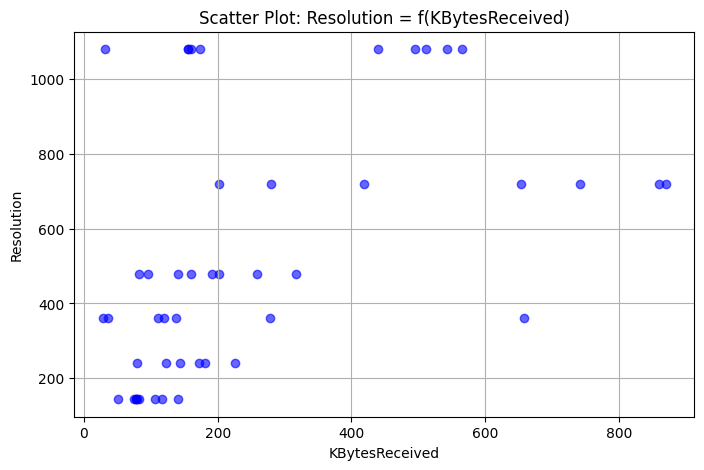

In [34]:
## TODO:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', alpha=0.6)
plt.xlabel("KBytesReceived")
plt.ylabel("Resolution")
plt.title("Scatter Plot: Resolution = f(KBytesReceived)")
plt.grid(True)
plt.savefig("scatter_plot.pdf")  # Save the figure as PDF
plt.show()

### Step 5: Manually Creating a Simple Regression Model

Before using a machine learning library, let’s build a very simple regression model "by hand" to understand the concept.

* c) Without using any machine learning libraries, define a simple linear model to predict `Resolution` from `KBytesReceived`. Choose a slope value of 1.

#### Answer:

In [35]:
## TODO:
beta1 = 1

beta0 = y.mean() - beta1 * X['KBytesReceived'].mean()

print(f"Manual regression coefficients:\nIntercept (beta0): {beta0:.3f}, Slope (beta1): {beta1}")

# Compute predictions using the manual model
y_manual_pred = beta0 + beta1 * X['KBytesReceived']

Manual regression coefficients:
Intercept (beta0): 279.271, Slope (beta1): 1


* d) Plot the resulting line over your earlier scatter plot to visually assess the fit. Save the new plot as `scatter_plot2.pdf`

#### Answer:

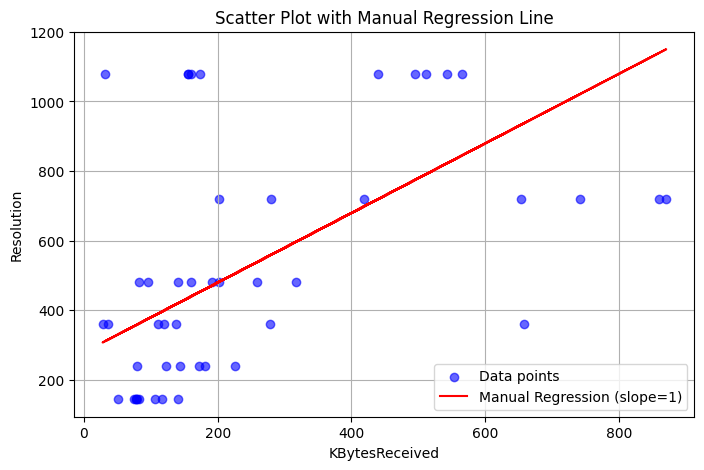

In [36]:
## TODO:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data points')
plt.plot(X, y_manual_pred, color='red', label='Manual Regression (slope=1)')
plt.xlabel("KBytesReceived")
plt.ylabel("Resolution")
plt.title("Scatter Plot with Manual Regression Line")
plt.legend()
plt.grid(True)
plt.savefig("scatter_plot2.pdf")  # Save as PDF
plt.show()

### Step 6: Train a Linear Regression Model Using Scikit-learn

Now that you've tried defining a model manually, let's use supervised learning to train a regression model that automatically finds the best slope (and intercept) to fit the data.

We'll use **Ordinary Least Squares (OLS)** — the most common type of linear regression — from `scikit-learn`.

* e) Create the regression model. 
    * **Hint:** Use `LinearRegression()` from `sklearn.linear_model`.

#### Answer:

In [37]:
## TODO:
model = LinearRegression()

* f) Fit the model using your full dataset. 
    * **Hint:** Use `.fit(...)`.

#### Answer:

In [38]:
## TODO:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


* g) Predict the output for a range of input values. 
    * **Hint:** Use `.predict(...)` on your model.

#### Answer:

In [39]:
## TODO:
X_range = np.linspace(X['KBytesReceived'].min(), X['KBytesReceived'].max(), 100).reshape(-1, 1)
X_range_df = pd.DataFrame(X_range, columns=['KBytesReceived'])

# Predict using the trained model
y_range_pred = model.predict(X_range_df)

* h) Plot the model’s predictions on top of your scatter plot. 
    * **Hint:** Use `ax.plot(...)` and add a legend with `ax.legend()`.

#### Answer:

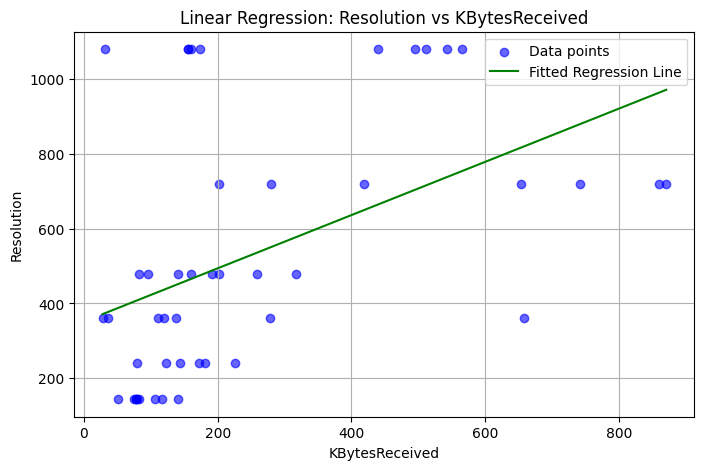

In [40]:
## TODO:
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(X, y, color='blue', alpha=0.6, label='Data points')
ax.plot(X_range, y_range_pred, color='green', linestyle='-', label='Fitted Regression Line')

ax.set_xlabel("KBytesReceived")
ax.set_ylabel("Resolution")
ax.set_title("Linear Regression: Resolution vs KBytesReceived")
ax.legend()
ax.grid(True)

plt.show()

* i) Print the learned model parameters: the intercept and slope. 
    * **Hint:** Use `.intercept_` and `.coef_ attributes` of the model.

#### Answer:

In [41]:
## TODO:
# Step 6i: Print learned model parameters
print(f"Learned intercept (beta0): {model.intercept_:.3f}")
print(f"Learned slope (beta1): {model.coef_[0]:.3f}")

Learned intercept (beta0): 351.761
Learned slope (beta1): 0.712


* j) Save the final figure as `final_figure.pdf`. 
    * **Hint:** Use `fig.savefig(...)`.

#### Answer:

In [42]:
## TODO:
fig.savefig("final_figure.pdf")
